**Inventory**

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from pathlib import Path

In [14]:
file_path = Path.cwd().parent.parent/"Excel"/"4_Inventory.xlsx"
df = pd.read_excel(file_path)
df

,Inventory_ID,Product_ID,Warehouse_ID,Date,Opening_Stock,Received_Qty,Sold_Qty,Damaged_Qty,Closing_Stock
0,INV100000,P1051,W109,2025-07-01,2185.0,325.0,672.0,3.0,1835.0
1,INV100001,P1976,W102,2025-08-12,1544.0,593.0,281.0,0.0,1856.0
2,INV100002,P1328,W107,2025-06-17,613.0,542.0,248.0,1.0,906.0
3,INV100003,P1097,,2025-01-04,521.0,522.0,372.0,2.0,669.0
4,INV100004,P1160,W110,2025-11-06,1146.0,256.0,340.0,0.0,1062.0
...,...,...,...,...,...,...,...,...,...
365725,INV457640,P1954,W111,2025-10-01,1810.0,100.0,143.0,3.0,1764.0
365726,INV429841,P1611,W115,2025-01-13,2108.0,398.0,248.0,3.0,2255.0
365727,INV276601,P1847,W101,2025-11-10,1546.0,486.0,702.0,0.0,1330.0
365728,INV430860,P1740,W106,2025-09-29,58.0,651.0,680.0,5.0,24.0


In [15]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365730 entries, 0 to 365729
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Inventory_ID   363504 non-null  object        
 1   Product_ID     363479 non-null  object        
 2   Warehouse_ID   363414 non-null  object        
 3   Date           363900 non-null  datetime64[ns]
 4   Opening_Stock  363902 non-null  float64       
 5   Received_Qty   363905 non-null  float64       
 6   Sold_Qty       363897 non-null  float64       
 7   Damaged_Qty    363900 non-null  float64       
 8   Closing_Stock  363899 non-null  float64       
dtypes: datetime64[ns](1), float64(5), object(3)
memory usage: 25.1+ MB


In [16]:
# Upper, Trimming and Consistent null values
columns = ["Inventory_ID", "Product_ID", "Warehouse_ID"]
for col in columns:
    df[col] = df[col].str.upper()
    df[col] = df[col].str.strip()
nulls = ["N/A", "NA", "Null", "NULL", "UNKNOWN", ""]
df.replace(nulls, np.nan, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365730 entries, 0 to 365729
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Inventory_ID   361655 non-null  object        
 1   Product_ID     361628 non-null  object        
 2   Warehouse_ID   361578 non-null  object        
 3   Date           363900 non-null  datetime64[ns]
 4   Opening_Stock  363902 non-null  float64       
 5   Received_Qty   363905 non-null  float64       
 6   Sold_Qty       363897 non-null  float64       
 7   Damaged_Qty    363900 non-null  float64       
 8   Closing_Stock  363899 non-null  float64       
dtypes: datetime64[ns](1), float64(5), object(3)
memory usage: 25.1+ MB


In [17]:
# Dropping duplicates except nulls
mask = df["Inventory_ID"].notna()
df = pd.concat([
    df[mask].drop_duplicates(subset=["Inventory_ID"], keep="first"),
    df[~mask]
]).sort_index()
df.reset_index(drop=True, inplace=True)
df.head()

,Inventory_ID,Product_ID,Warehouse_ID,Date,Opening_Stock,Received_Qty,Sold_Qty,Damaged_Qty,Closing_Stock
0,INV100000,P1051,W109,2025-07-01,2185.0,325.0,672.0,3.0,1835.0
1,INV100001,P1976,W102,2025-08-12,1544.0,593.0,281.0,0.0,1856.0
2,INV100002,P1328,W107,2025-06-17,613.0,542.0,248.0,1.0,906.0
3,INV100003,P1097,NaN,2025-01-04,521.0,522.0,372.0,2.0,669.0
4,INV100004,P1160,W110,2025-11-06,1146.0,256.0,340.0,0.0,1062.0


In [18]:
# Replacing null values in Inventory ID
for i in range(len(df)):
    value = df.loc[i, "Inventory_ID"]
    if not pd.notna(value):
        df.loc[i, "Inventory_ID"] = f"INV{100000+i}"
df["Inventory_ID"].isna().sum()
df["Inventory_ID"].duplicated().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365010 entries, 0 to 365009
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Inventory_ID   365010 non-null  object        
 1   Product_ID     360919 non-null  object        
 2   Warehouse_ID   360863 non-null  object        
 3   Date           363184 non-null  datetime64[ns]
 4   Opening_Stock  363185 non-null  float64       
 5   Received_Qty   363185 non-null  float64       
 6   Sold_Qty       363185 non-null  float64       
 7   Damaged_Qty    363185 non-null  float64       
 8   Closing_Stock  363185 non-null  float64       
dtypes: datetime64[ns](1), float64(5), object(3)
memory usage: 25.1+ MB


In [19]:
purchases_path = Path.cwd().parent.parent/"Excel"/"7_Purchases.xlsx"
purchases_df = pd.read_excel(purchases_path)
purchases_df

,Purchase_ID,Supplier_ID,Product_ID,Warehouse_ID,Purchase_Date,Quantity,Unit_Cost,Expected_Date,Actual_Date
0,PUR1000000,S105,P1063,W107,2025-05-01,691.0,514.16,2025-05-12,2025-05-17
1,PUR1000001,S184,P1355,W107,2025-01-23,1946.0,349.72,2025-01-25,2025-02-06
2,PUR1000002,S155,P1180,W114,2025-06-05,658.0,206.50,2025-07-04,2025-07-04
3,PUR1000003,S101,P1598,W116,2025-06-11,80.0,108.78,2025-07-08,2025-07-10
4,PUR1000004,S121,P1083,W112,2025-07-18,1082.0,121.36,2025-08-08,2025-08-06
...,...,...,...,...,...,...,...,...,...
75145,PUR1040422,S196,P1742,W114,2025-10-09,2684.0,171.29,2025-10-29,2025-10-31
75146,PUR1046443,S113,P1452,W101,2025-11-07,1546.0,130.48,2025-11-18,2025-11-19
75147,PUR1026155,S156,P1590,W114,2025-01-02,2768.0,85.25,2025-02-01,2025-02-01
75148,PUR1010759,S193,P1706,W105,2025-12-06,942.0,135.20,2025-12-15,2025-12-16


In [20]:
# Mapping Product ID with Warehouse ID
purchases_df["Product_ID"] = purchases_df["Product_ID"].str.upper()
purchases_df["Warehouse_ID"] = purchases_df["Warehouse_ID"].str.upper()
mapping = (
  purchases_df.dropna(subset=["Product_ID"])
    .drop_duplicates(subset=["Warehouse_ID"])
    .set_index("Warehouse_ID")["Product_ID"]
    .to_dict()
)
df["Product_ID"] = df["Product_ID"].fillna(df["Warehouse_ID"].map(mapping))
df["Product_ID"].isna().sum()

np.int64(0)

In [21]:
# Mapping Product ID with Warehouse ID
mapping = (
    purchases_df.dropna(subset=["Warehouse_ID"])
      .drop_duplicates(subset=["Product_ID"])
      .set_index("Product_ID")["Warehouse_ID"]
      .to_dict()
)
df["Warehouse_ID"] = df["Warehouse_ID"].fillna(df["Product_ID"].map(mapping))
df["Warehouse_ID"].isna().sum()

np.int64(0)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365010 entries, 0 to 365009
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Inventory_ID   365010 non-null  object        
 1   Product_ID     365010 non-null  object        
 2   Warehouse_ID   365010 non-null  object        
 3   Date           363184 non-null  datetime64[ns]
 4   Opening_Stock  363185 non-null  float64       
 5   Received_Qty   363185 non-null  float64       
 6   Sold_Qty       363185 non-null  float64       
 7   Damaged_Qty    363185 non-null  float64       
 8   Closing_Stock  363185 non-null  float64       
dtypes: datetime64[ns](1), float64(5), object(3)
memory usage: 25.1+ MB


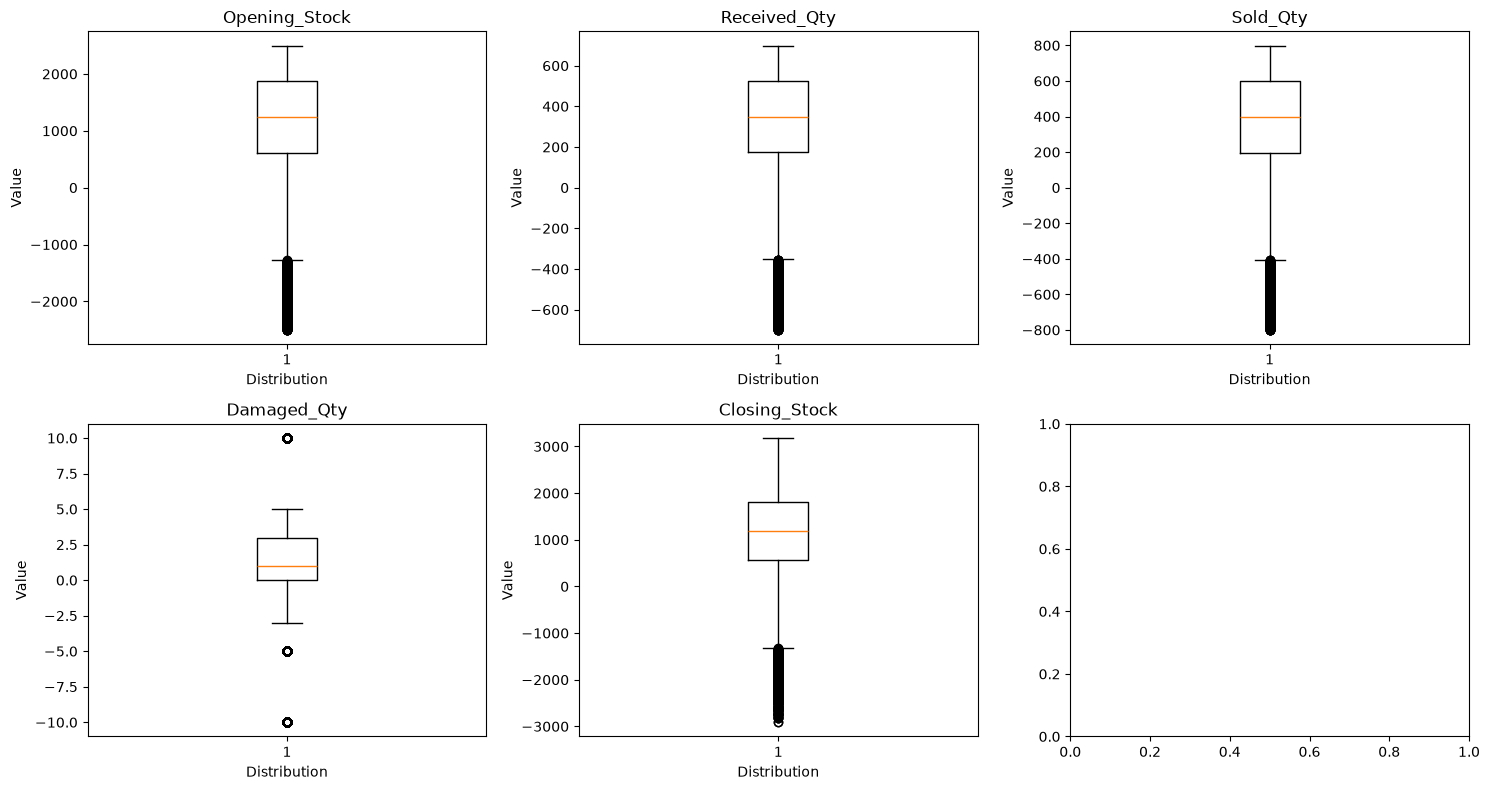

In [23]:
# Checking negatives or outliers in data
def Show_Plots():
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    columns = [
        "Opening_Stock", "Received_Qty", "Sold_Qty", "Damaged_Qty", "Closing_Stock"
    ]
    for ax, col in zip(axes.flat, columns):
        ax.boxplot(df[col].dropna())
        ax.set_title(col)
        ax.set_xlabel("Distribution")
        ax.set_ylabel("Value")

    plt.tight_layout()
    plt.show()

Show_Plots()

In [24]:
# Correcting negative values
df.loc[df["Opening_Stock"]<0, "Opening_Stock"] *= -1
df.loc[df["Received_Qty"]<0, "Received_Qty"] *= -1
df.loc[df["Sold_Qty"]<0, "Sold_Qty"] *= -1
df.loc[df["Damaged_Qty"]<0, "Damaged_Qty"] *= -1
df.loc[df["Closing_Stock"]<0, "Closing_Stock"] *= -1

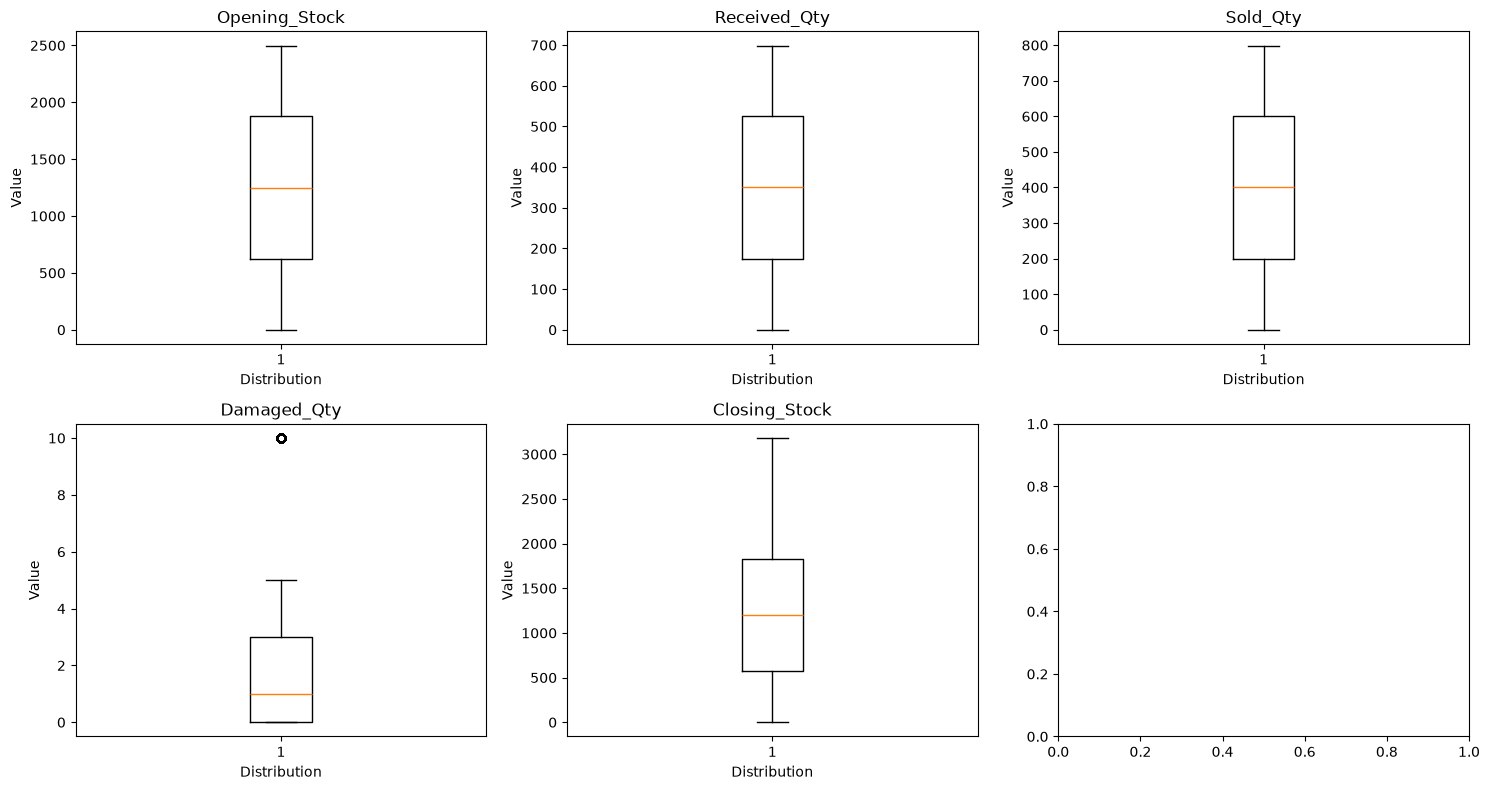

In [25]:
Show_Plots()

In [34]:
opening_stock = (df["Sold_Qty"].fillna(df["Sold_Qty"].median())
                 +df["Damaged_Qty"].fillna(df["Damaged_Qty"].median())
                 +df["Closing_Stock"].fillna(df["Closing_Stock"].median())
                 -df["Received_Qty"].fillna(df["Received_Qty"].median())).round(0)
df.loc[df["Opening_Stock"].isna(), "Opening_Stock"] = opening_stock
(df["Opening_Stock"]<0).sum()

np.int64(0)

In [35]:
received_qty = (df["Sold_Qty"].fillna(df["Sold_Qty"].median())
                 +df["Damaged_Qty"].fillna(df["Damaged_Qty"].median())
                 +df["Closing_Stock"].fillna(df["Closing_Stock"].median())
                 -df["Opening_Stock"].fillna(df["Opening_Stock"].median())).round(0)
df.loc[df["Received_Qty"].isna(), "Received_Qty"] = received_qty
df.loc[df["Received_Qty"]<0, "Received_Qty"] *= -1
(df["Received_Qty"]<0).sum()

np.int64(0)

In [36]:
sold_qty = (df["Opening_Stock"].fillna(df["Opening_Stock"].median())
                 +df["Received_Qty"].fillna(df["Received_Qty"].median())
                 -df["Damaged_Qty"].fillna(df["Damaged_Qty"].median())
                 -df["Closing_Stock"].fillna(df["Closing_Stock"].median())).round(0)
df.loc[df["Sold_Qty"].isna(), "Sold_Qty"] = sold_qty
df.loc[df["Sold_Qty"]<0, "Sold_Qty"] = 0
(df["Sold_Qty"]<0).sum()

np.int64(0)

In [37]:
damaged_qty = (df["Opening_Stock"].fillna(df["Opening_Stock"].median())
                 +df["Received_Qty"].fillna(df["Received_Qty"].median())
                 -df["Sold_Qty"].fillna(df["Sold_Qty"].median())
                 -df["Closing_Stock"].fillna(df["Closing_Stock"].median())).round(0)
df.loc[df["Damaged_Qty"].isna(), "Damaged_Qty"] = damaged_qty
df.loc[df["Damaged_Qty"]<0, "Damaged_Qty"] = 0
(df["Damaged_Qty"]<0).sum()

np.int64(0)

In [38]:
closing_stock = (df["Opening_Stock"].fillna(df["Opening_Stock"].median())
                 +df["Received_Qty"].fillna(df["Received_Qty"].median())
                 -df["Sold_Qty"].fillna(df["Sold_Qty"].median())
                 -df["Damaged_Qty"].fillna(df["Damaged_Qty"].median())).round(0)
df.loc[df["Closing_Stock"].isna(), "Closing_Stock"] = closing_stock
(df["Closing_Stock"]<0).sum()

np.int64(113)

In [39]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365010 entries, 0 to 365009
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Inventory_ID   365010 non-null  object        
 1   Product_ID     365010 non-null  object        
 2   Warehouse_ID   365010 non-null  object        
 3   Date           363184 non-null  datetime64[ns]
 4   Opening_Stock  365010 non-null  float64       
 5   Received_Qty   365010 non-null  float64       
 6   Sold_Qty       365010 non-null  float64       
 7   Damaged_Qty    365010 non-null  float64       
 8   Closing_Stock  365010 non-null  float64       
dtypes: datetime64[ns](1), float64(5), object(3)
memory usage: 25.1+ MB


In [41]:
df.to_csv("../../Data/Cleaned/Inventory.csv", index=False)